In [1]:
import pooch
import datalad
import spikeinterface as si

print("SpikeInterface:", si.__version__)
print("pooch:", pooch.__version__)
print("DataLad:", datalad.__version__)

c:\Users\Bin\miniconda3\envs\spike_sort\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
It is highly recommended to configure Git before using DataLad. Set both 'user.name' and 'user.email' configuration variables.


SpikeInterface: 0.105.0
pooch: v1.9.0
DataLad: 1.6.5


In [2]:
import spikeinterface.extractors as se

local_path = r".\mearec_test_10s.h5"

recording, sorting_gt = se.read_mearec(local_path)

print(recording)
print(sorting_gt)

MEArecRecordingExtractor: 32 channels - 32.0kHz - 1 segments - 320,000 samples - 10.00s 
                          float32 dtype - 39.06 MiB
  file_path: d:\data_analysis\pre_exp2026928\pre_exp\mearec_test_10s.h5
MEArecSortingExtractor: 10 units - 1 segments - 32.0kHz
  file_path: d:\data_analysis\pre_exp2026928\pre_exp\mearec_test_10s.h5


In [3]:
print("通道数:", recording.get_num_channels())
print("采样率:", recording.get_sampling_frequency())
print("时长:", recording.get_total_duration())
print("总采样点:", recording.get_num_samples())

print("\nChannel IDs:")
print(recording.get_channel_ids())

print("\nGround-truth Unit IDs:")
print(sorting_gt.get_unit_ids())

通道数: 32
采样率: 32000.0
时长: 10.0
总采样点: 320000

Channel IDs:
['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29' '30'
 '31' '32']

Ground-truth Unit IDs:
['#0' '#1' '#2' '#3' '#4' '#5' '#6' '#7' '#8' '#9']


In [4]:
unit_id = sorting_gt.get_unit_ids()[0]

spike_samples = sorting_gt.get_unit_spike_train(unit_id)

fs = recording.get_sampling_frequency()
spike_times = spike_samples / fs

print("Unit:", unit_id)
print("Spike 数量:", len(spike_samples))
print("前20个 spike 时间 (s):")
print(spike_times[:20])

Unit: #0
Spike 数量: 53
前20个 spike 时间 (s):
[0.16240625 0.26290625 0.410125   0.481875   0.48428125 0.489625
 0.52903125 0.61271875 1.72209375 1.845625   1.9049375  3.28728125
 3.29903125 3.6588125  3.72634375 3.7289375  3.82165625 3.83990625
 4.13790625 4.3593125 ]


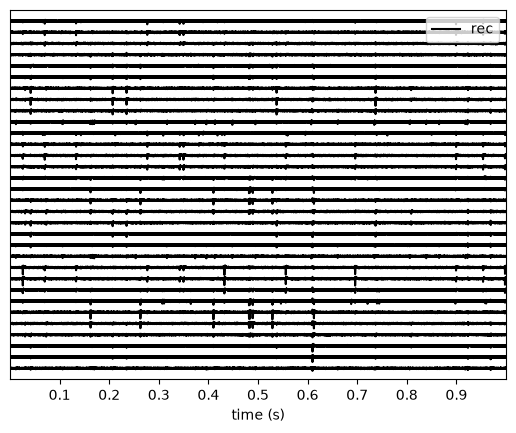

In [5]:
import matplotlib.pyplot as plt
import spikeinterface.widgets as sw

# 显示 0~1 s 的原始多通道数据
sw.plot_traces(
    recording,
    time_range=(0, 1),
    mode="line"
)

plt.show()

In [6]:
fs = recording.get_sampling_frequency()

traces = recording.get_traces(
    start_frame=0,
    end_frame=int(fs * 1)
)

print("Sampling frequency:", fs)
print("Data shape:", traces.shape)
print(traces[:10, :5])

Sampling frequency: 32000.0
Data shape: (32000, 32)
[[  1.976842     9.365089   -21.737356    -5.611787    11.229752  ]
 [  9.548397     2.1520123    1.2643261    0.40777588   5.4012833 ]
 [ 10.740664    -7.4031096   17.23787     17.794846    -3.9837914 ]
 [  0.16757536 -14.787041     1.4120197    5.582898    -6.310481  ]
 [-34.345818   -14.777086    -0.14733982  23.199947    -4.4220595 ]
 [ -4.4575515  -14.33397      4.263128     9.815481    -2.3374522 ]
 [-14.615725   -25.15816     11.580964    -5.3102293   -2.9146042 ]
 [ 19.663376   -19.178867    10.0678215  -10.762109   -16.467499  ]
 [ 15.581224   -46.15991      1.9898539  -20.734283   -10.070374  ]
 [  7.014859   -32.361702    21.204819    -3.0075488  -21.362007  ]]


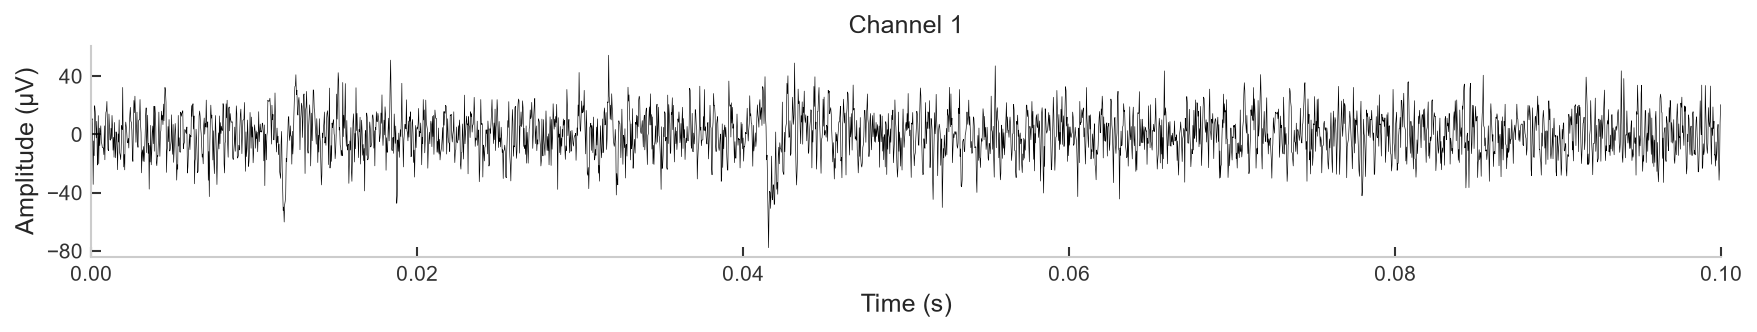

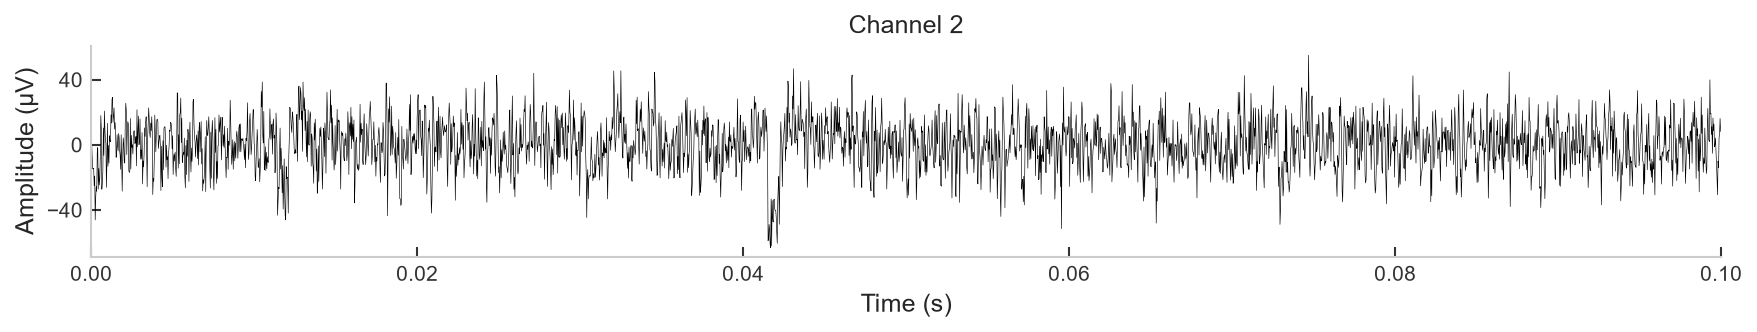

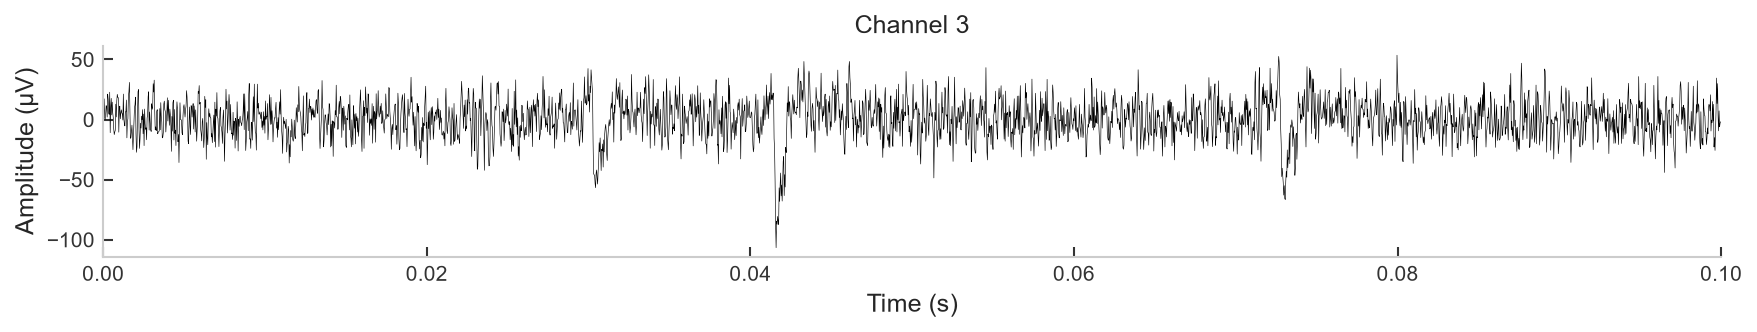

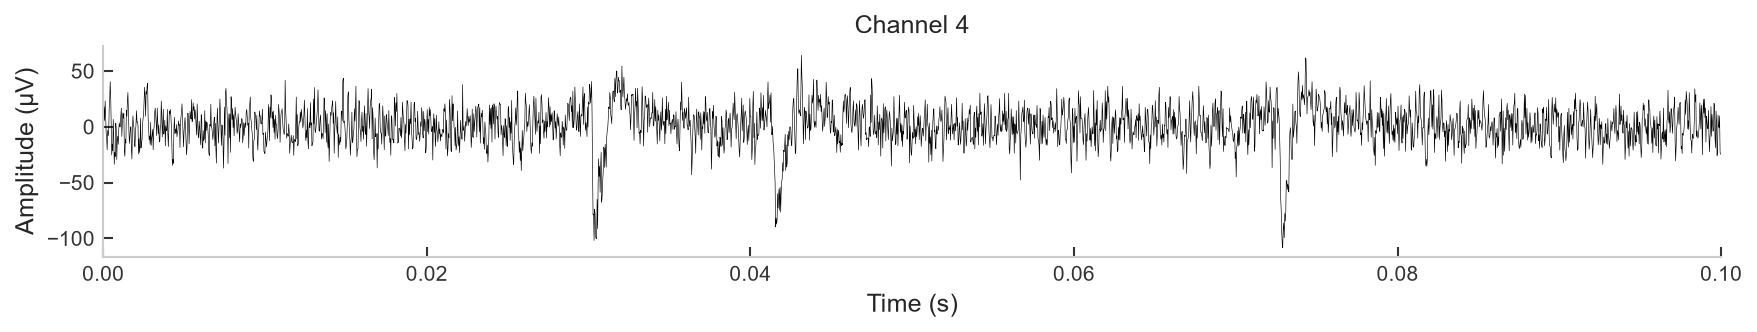

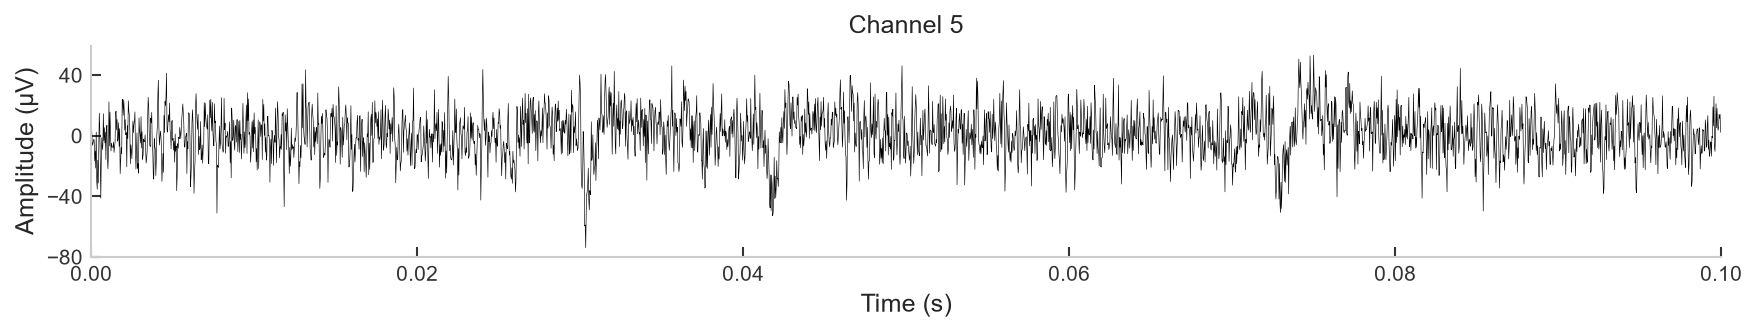

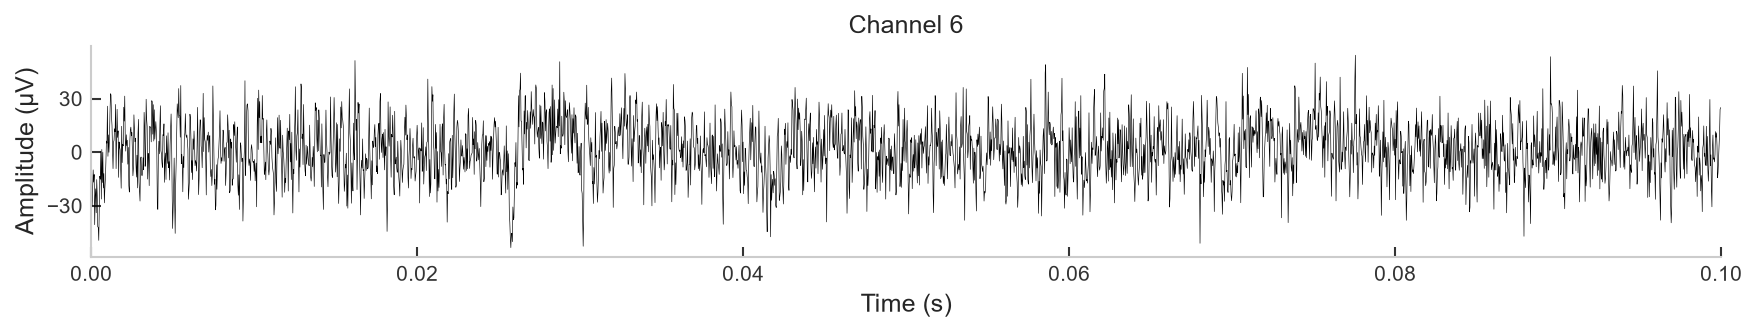

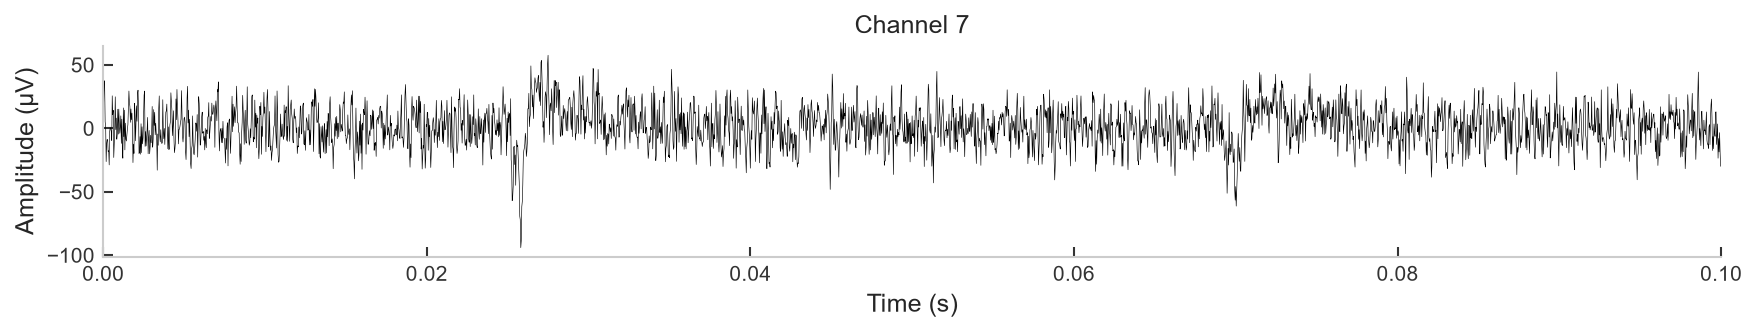

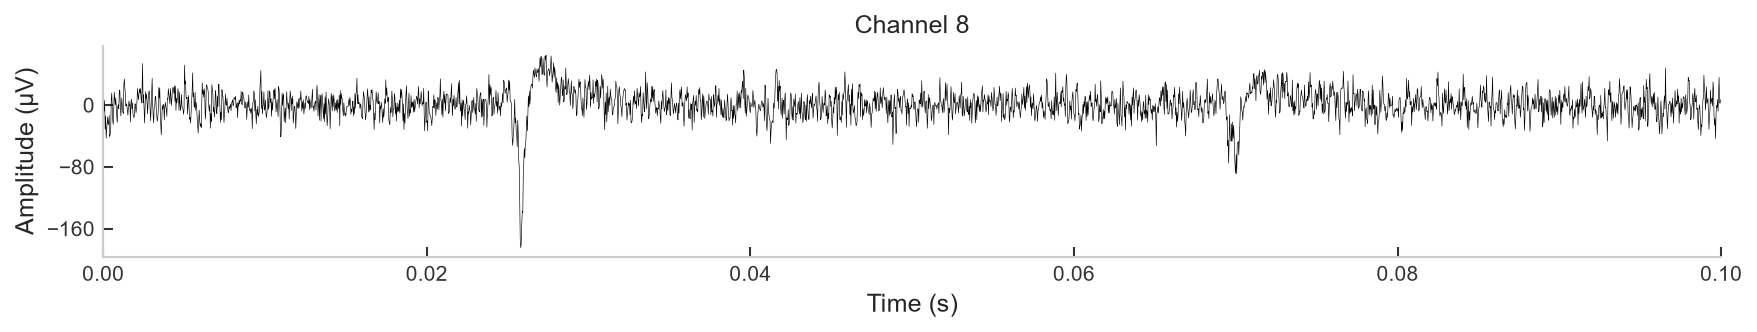

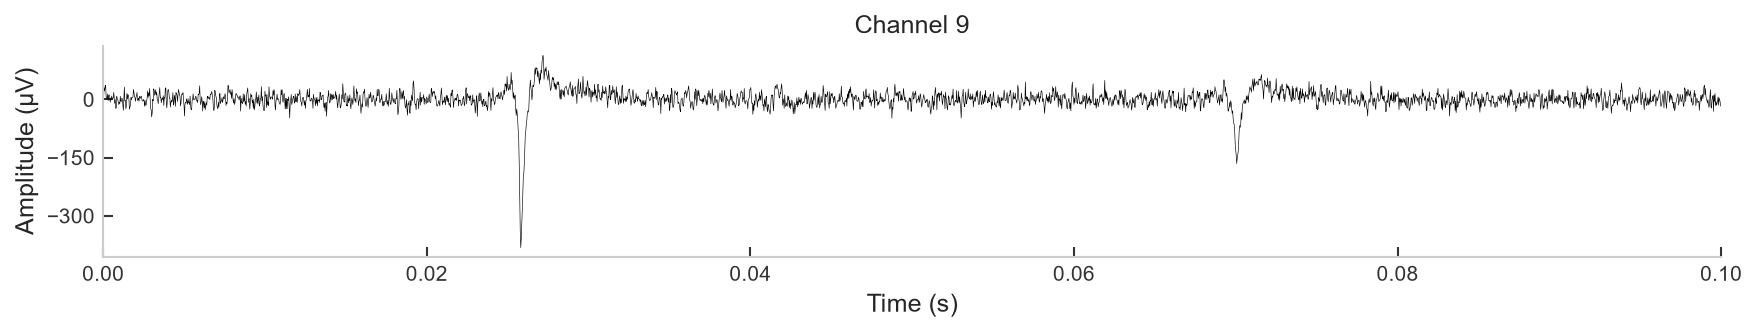

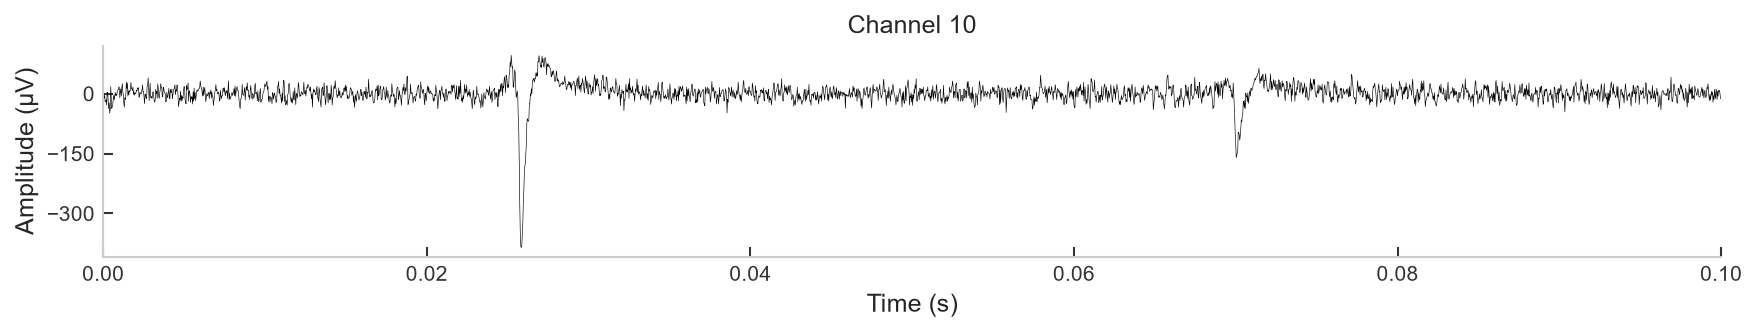

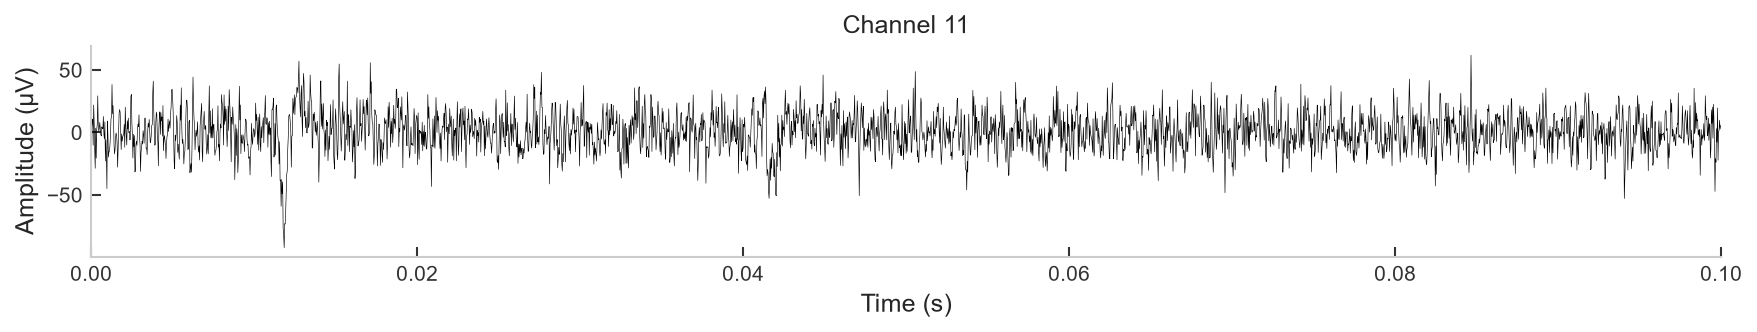

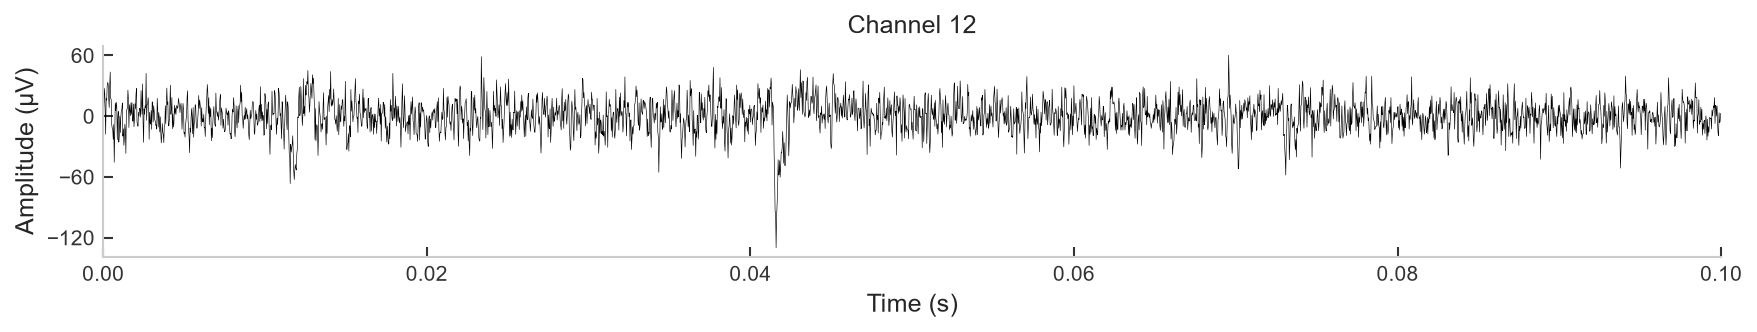

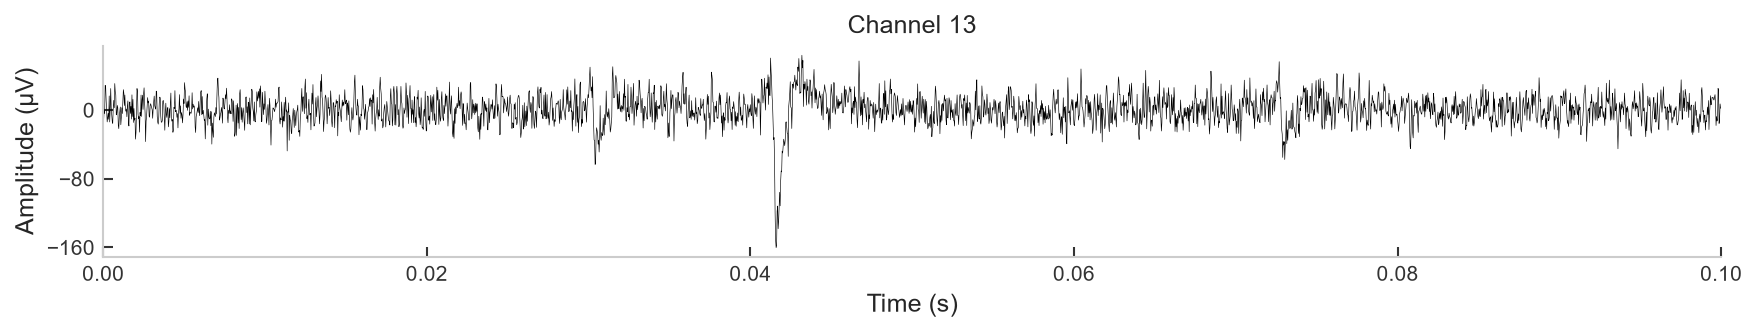

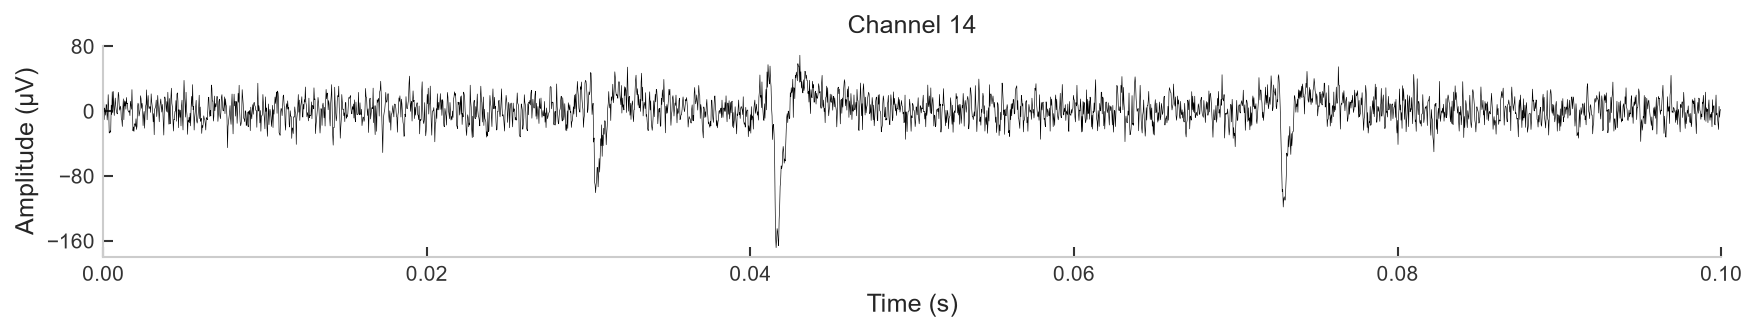

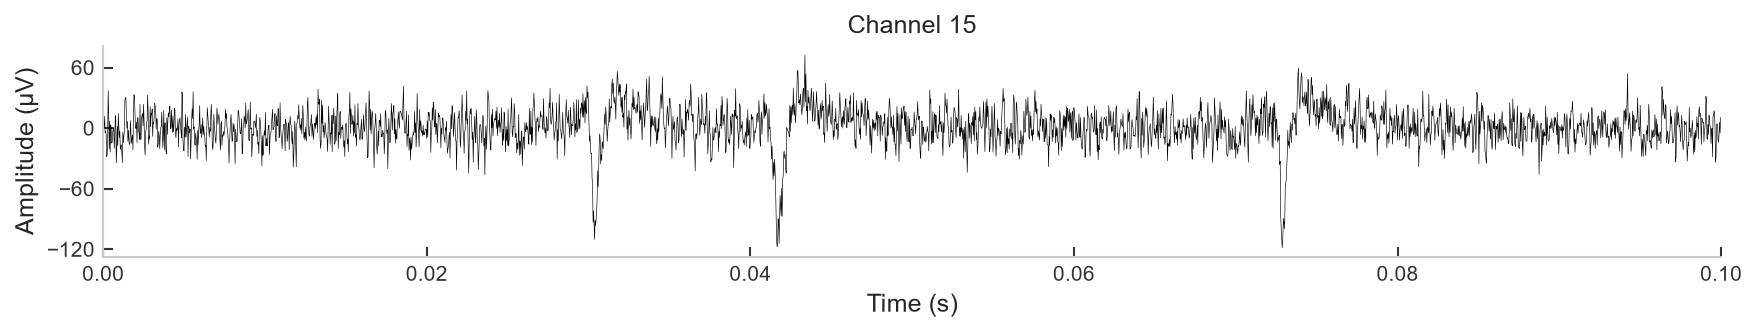

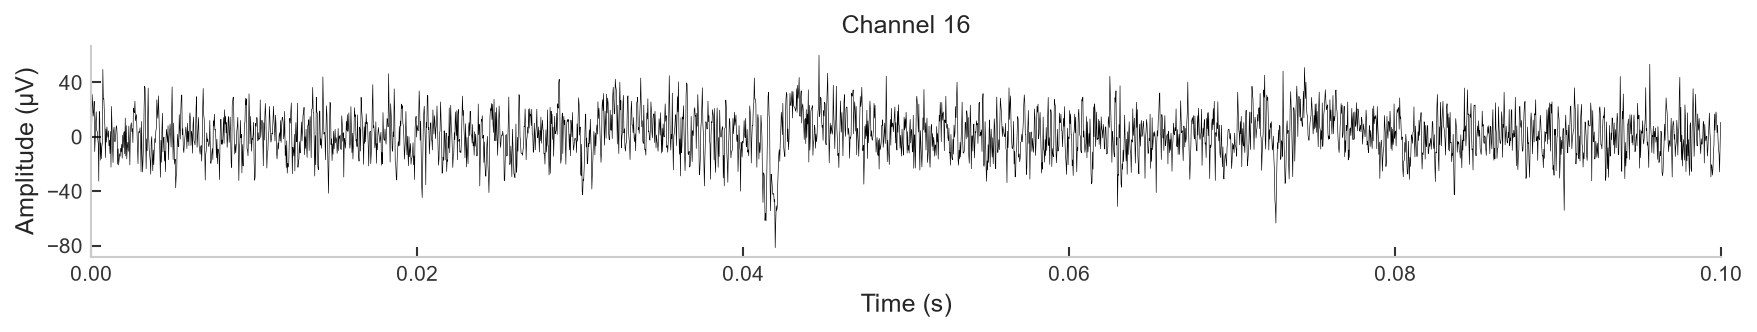

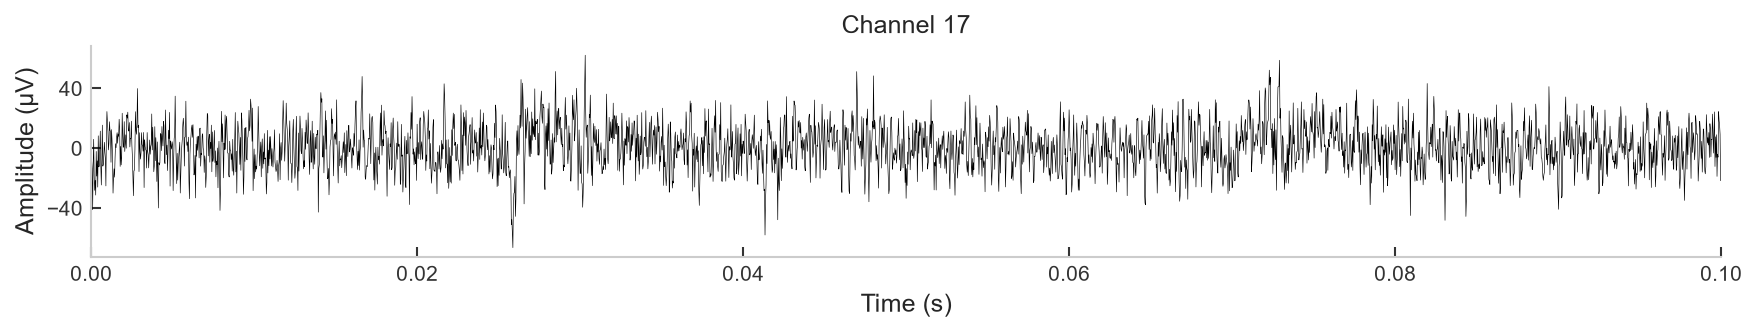

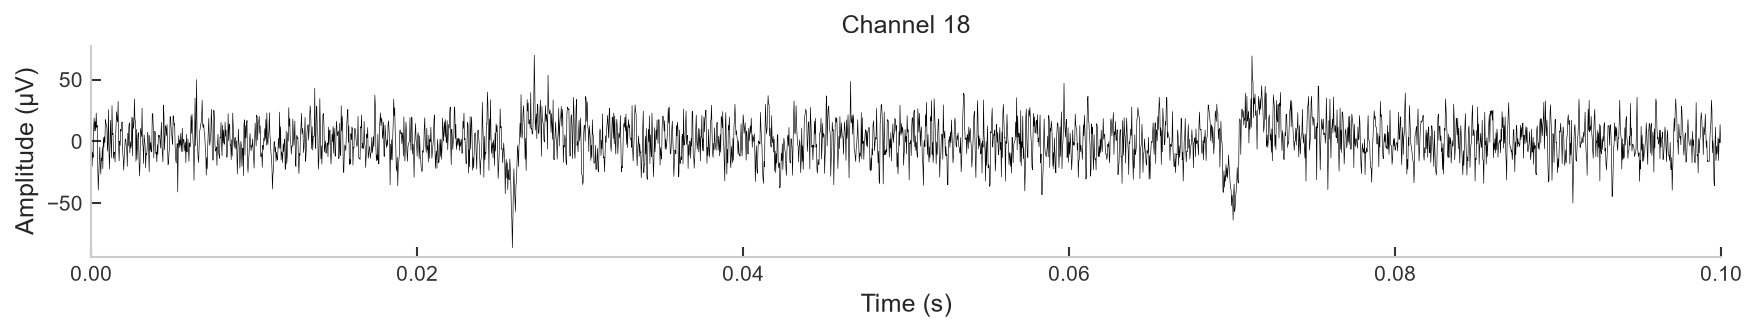

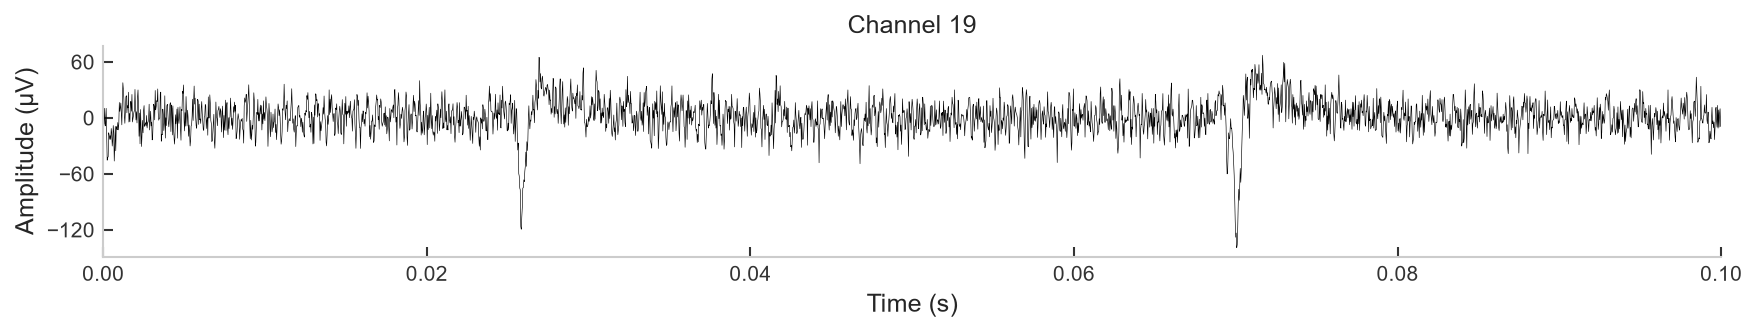

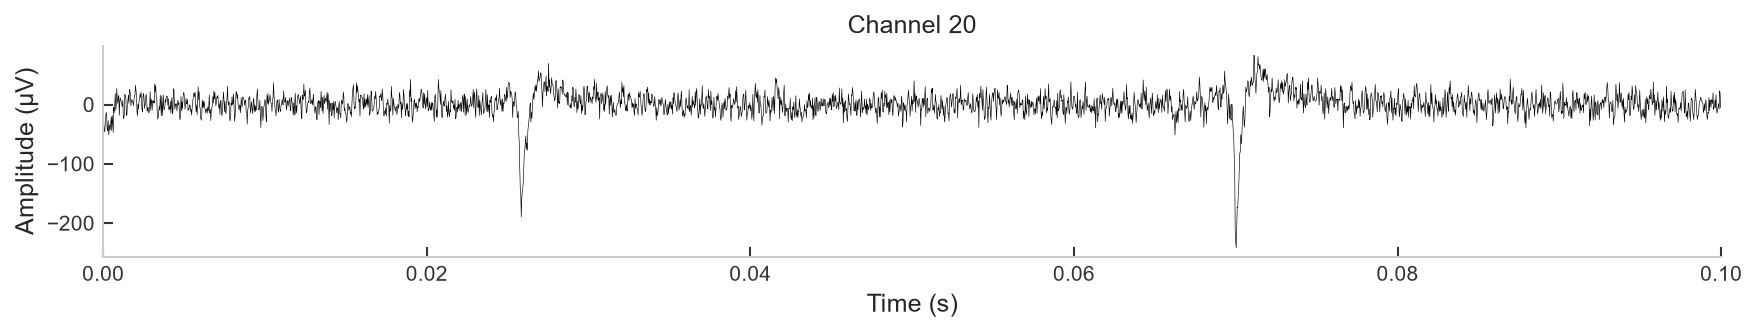

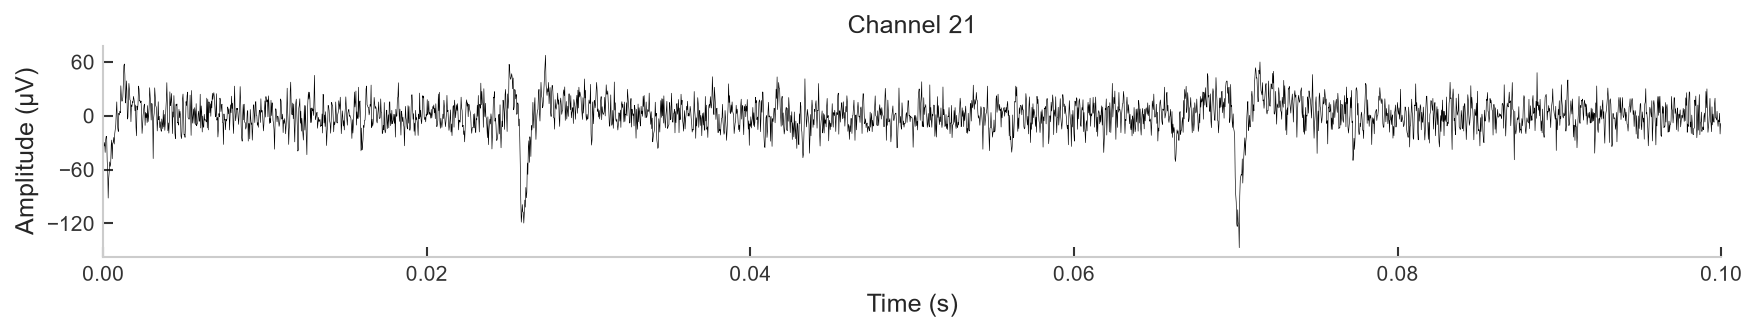

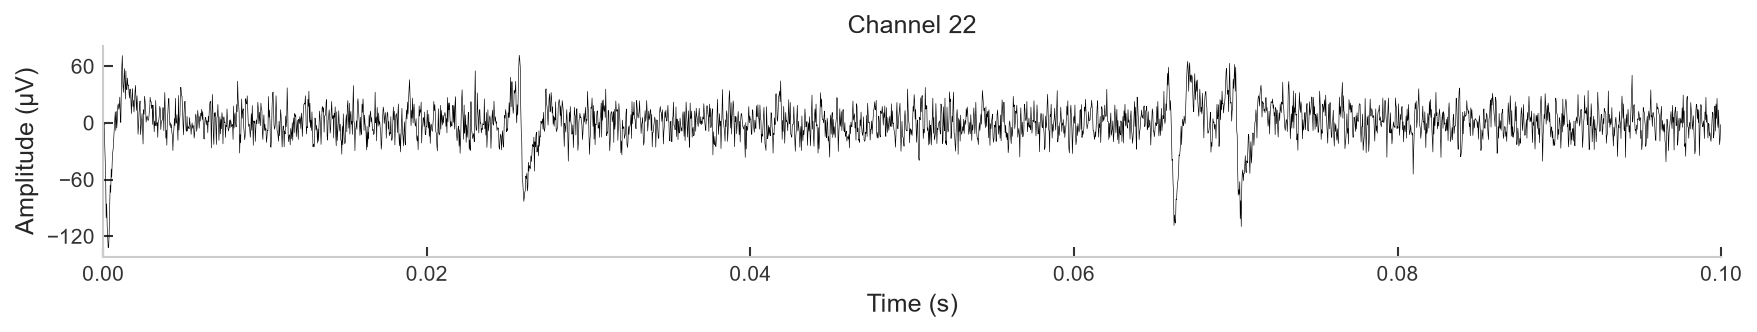

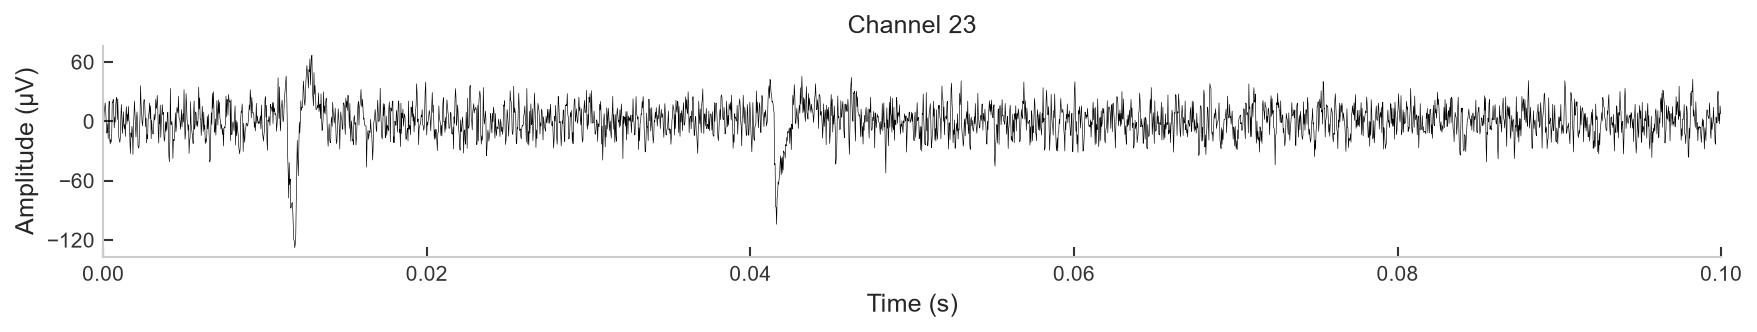

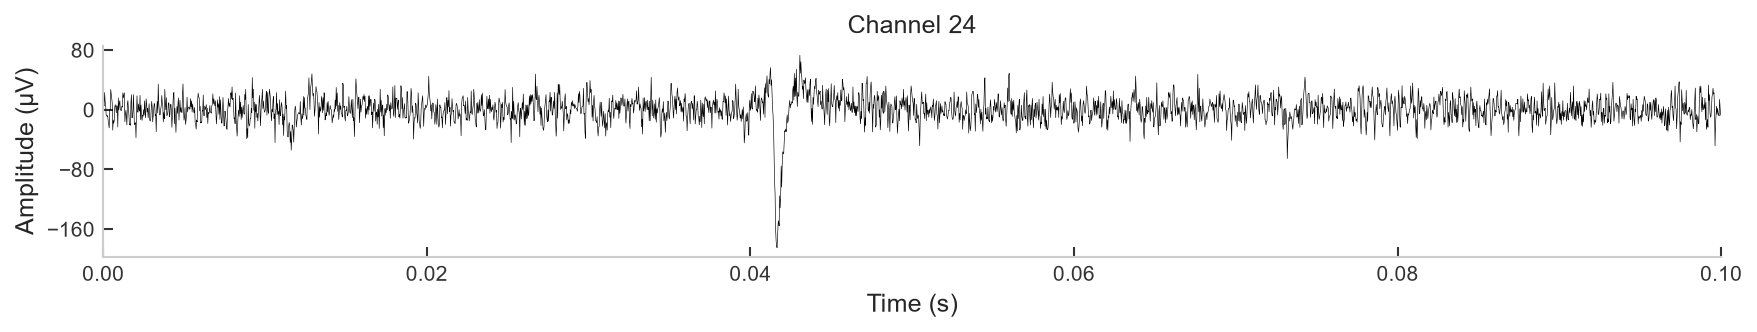

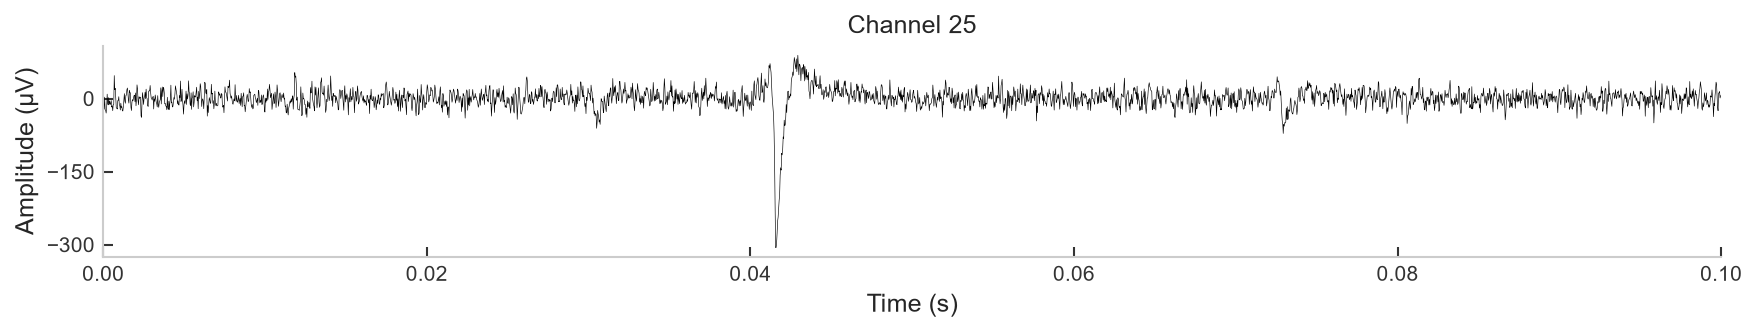

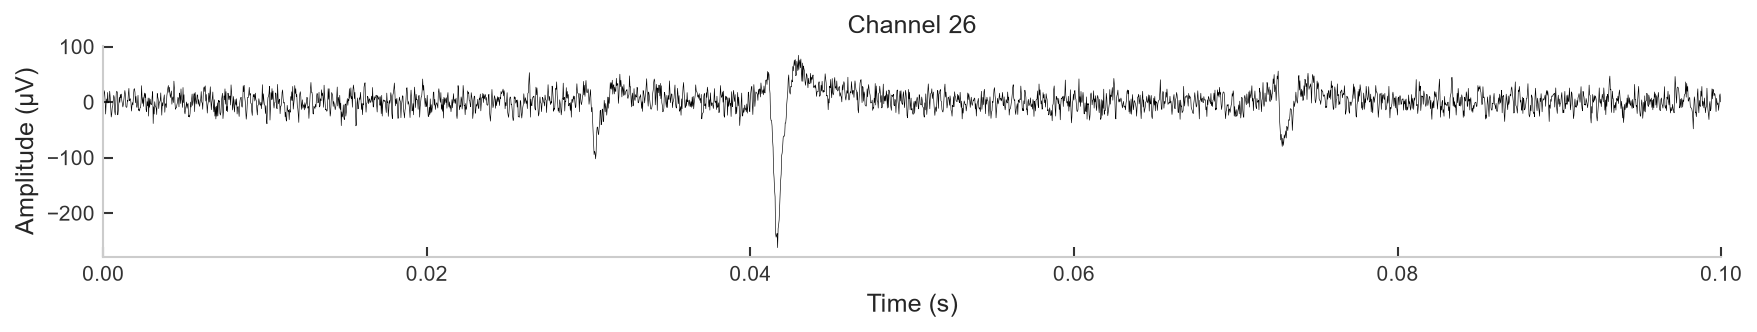

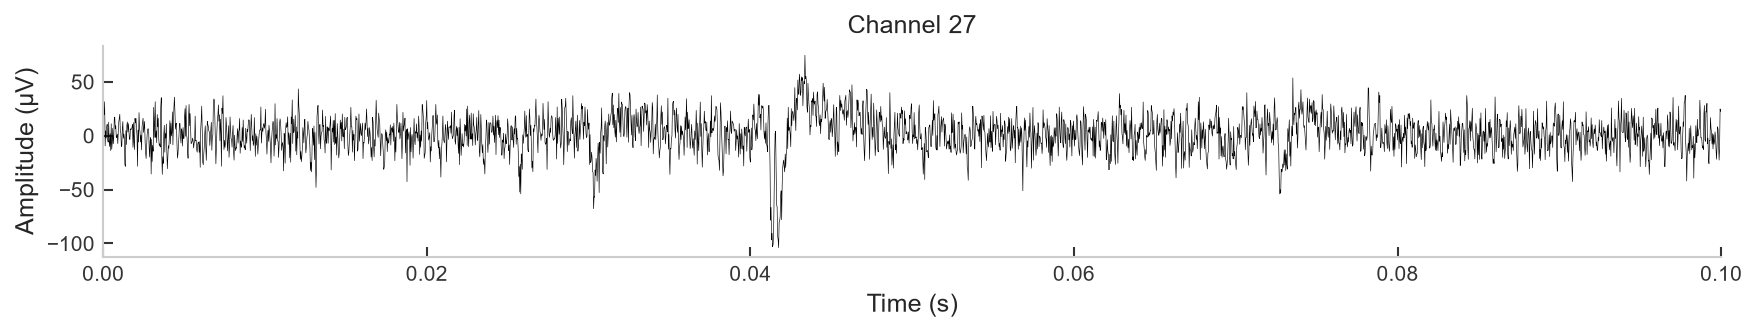

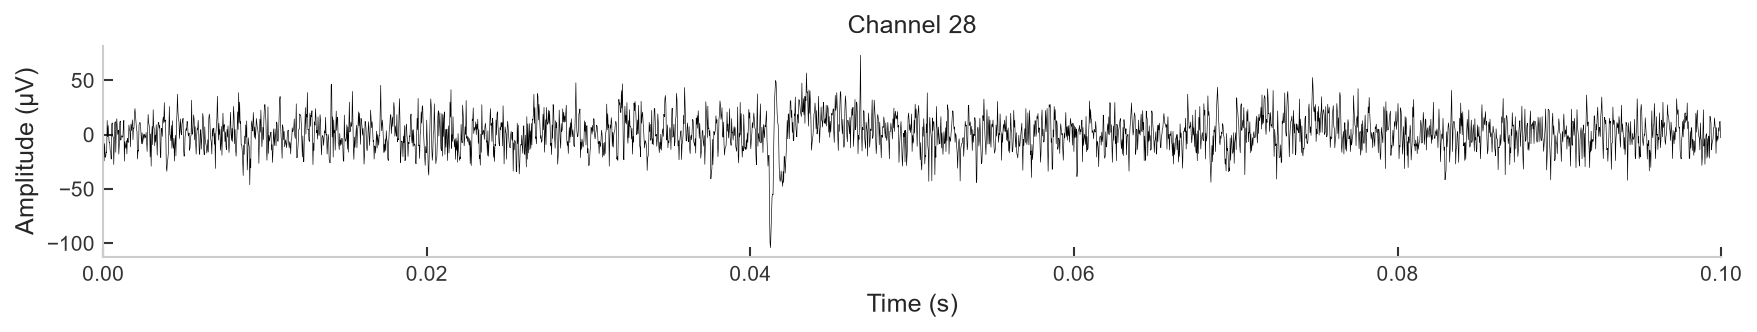

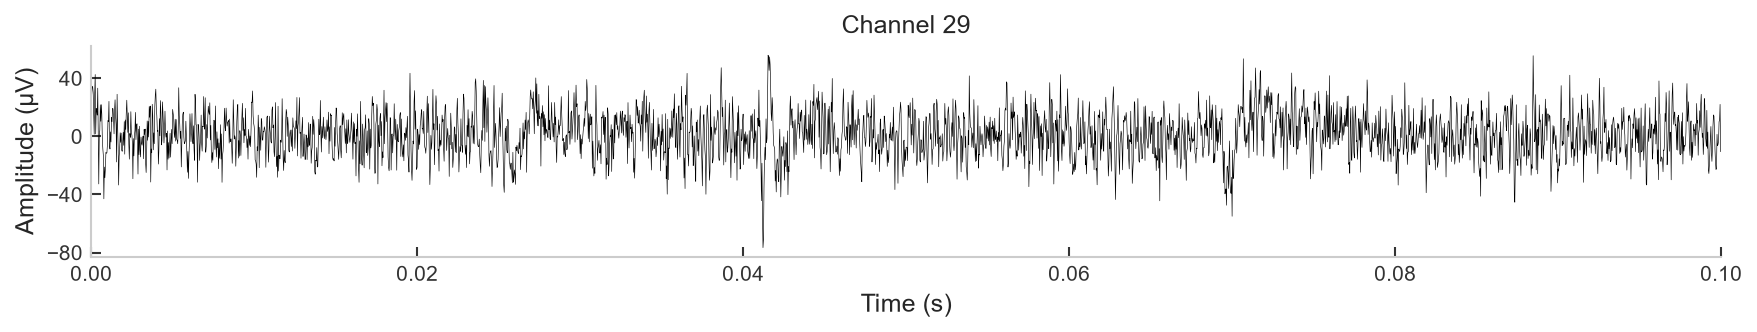

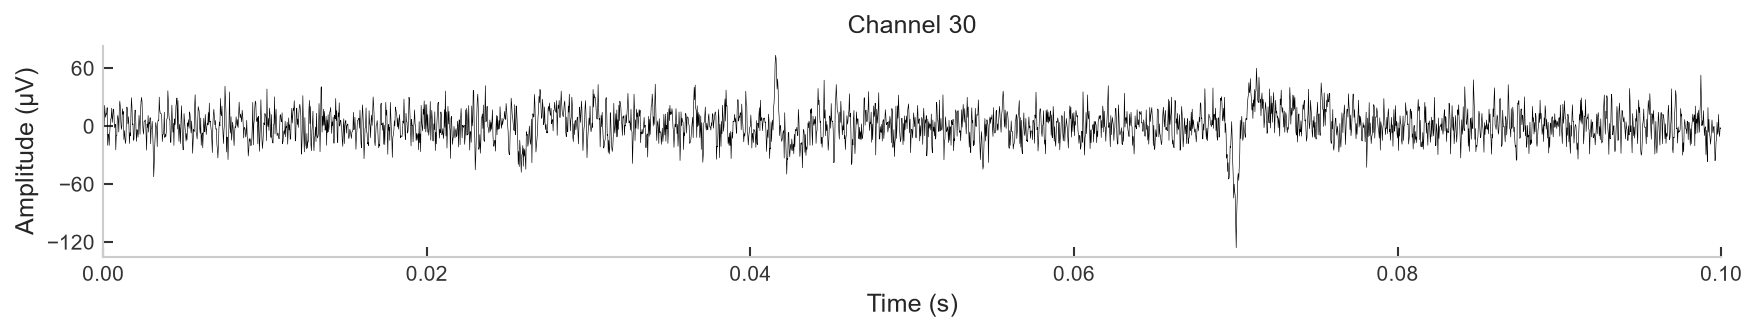

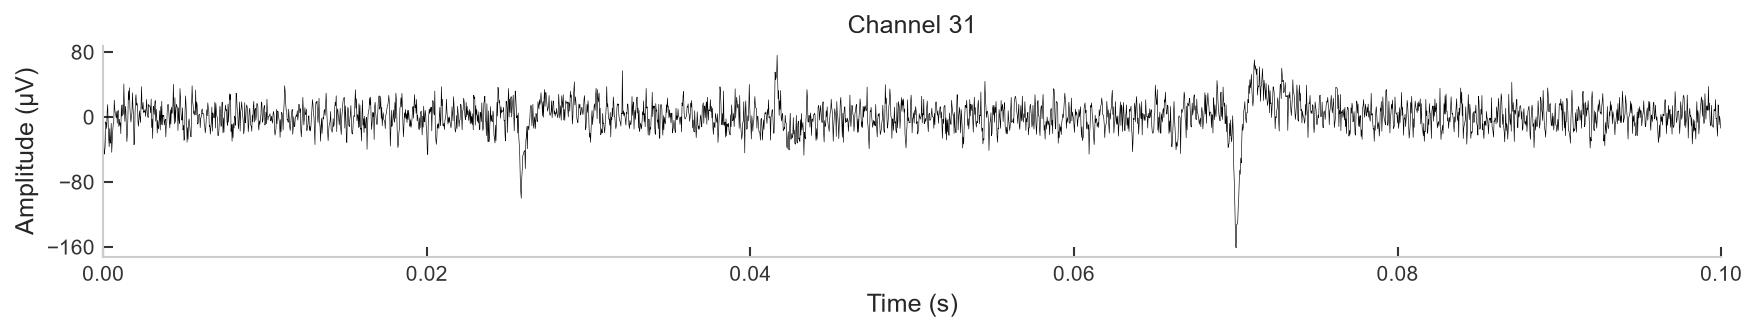

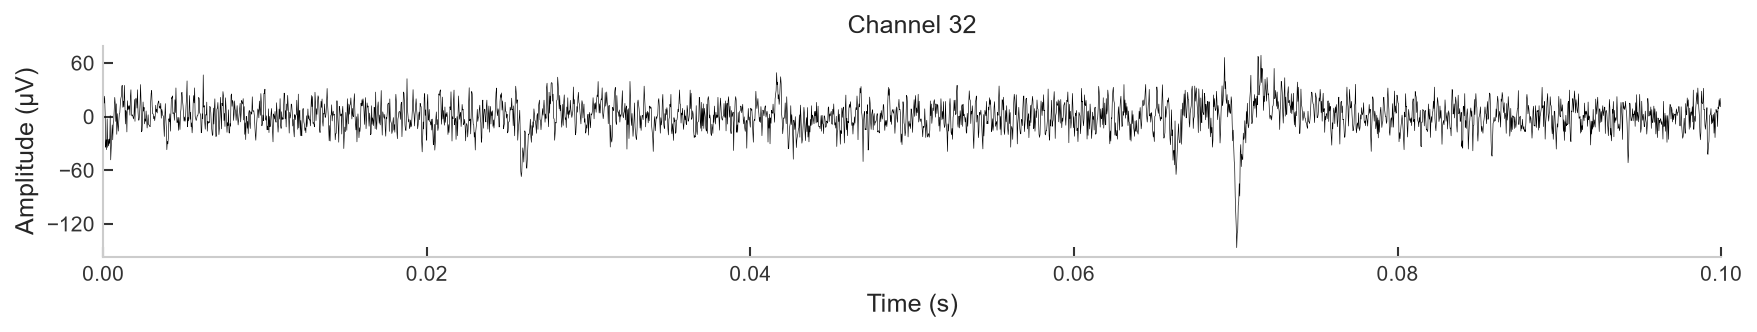

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import MaxNLocator

# =========================
# 参数
# =========================
start_time = 0       # 起始时间，s
end_time = 0.1         # 结束时间，s

# 获取采样率
fs = recording.get_sampling_frequency()

# 获取全部通道
channel_ids = recording.get_channel_ids()

# 时间转换为采样点
start_frame = int(start_time * fs)
end_frame = int(end_time * fs)

# 提取原始数据
# shape = (n_samples, n_channels)
traces = recording.get_traces(
    start_frame=start_frame,
    end_frame=end_frame,
    channel_ids=channel_ids
)

# 构造时间轴
time = np.arange(traces.shape[0]) / fs + start_time

# =========================
# 每个 channel 单独绘图
# =========================
for i, ch in enumerate(channel_ids):

    fig, ax = plt.subplots(figsize=(12, 2.5), dpi=150)
    plt.rcParams.update({'font.sans-serif': 'Arial'})
    ax.plot(
        time,
        traces[:, i],
        linewidth=0.3,
        color="black"
    )

    ax.set_title(f"Channel {ch}",fontsize=12)
    ax.set_xlabel("Time (s)",fontsize=12)
    ax.set_ylabel("Amplitude (μV)",fontsize=12)

    ax.set_xlim(start_time, end_time)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(1.0)
    ax.spines["bottom"].set_linewidth(1.0)
    ax.grid(False)
    ax.xaxis.set_major_locator(MultipleLocator(0.02)) # x轴间隔0.02
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))  # 只取整数
    ax.tick_params(
    axis="both",             # "x" / "y" / "both"
    which="major",           # "major" / "minor" / "both"
    labelsize=10,            # ★ 刻度标签字号
    labelcolor="#333333",    # 标签颜色
    labelrotation=0,         # 标签旋转
    pad=4,                   # 标签与刻度线间距
    direction="in",          # 刻度线方向
    length=5,                # 刻度线长度
    width=1.0,               # 刻度线粗细
    color="#333333",       # 刻度线颜色
    top=False,               # 顶部刻度
    right=False,             # 右侧刻度
    bottom=True,              # 底部刻度    
    left=True,                # 左侧刻度    
    )
    plt.tight_layout()
    plt.show()